# Manajemen Risiko Modal Kecil (Rp400.000) — Target Harian vs Kenyataan

### Permintaan user
- Modal **Rp400.000** ("kalau modal kecil bisa untung, apalagi modal besar").
- Rugi harian **0**, paling buruk **Rp10.000/hari**; tidak boleh minus.
- Profit minimal **$2/hari**, diusahakan **Rp30.000/hari** → sebulan untuk bayar VPS + jajan.

### Asumsi (perlu dikonfirmasi)
| Asumsi | Nilai |
|---|---|
| Kurs | Rp16.300 / USD → modal ≈ **$24.5** |
| Order minimum Binance spot | **$5** per order (filter `MIN_NOTIONAL`); Tokocrypto perlu dicek |
| Biaya | 0.15% per sisi (fee 0.1% + slippage 0.05%) |
| Strategi | 13 (BTC saja, H8b) dan V2 (portofolio 8 coin, notebook 15) |

Notebook ini **tidak mencari strategi baru** — hanya menerjemahkan hasil yang sudah ada ke Rupiah harian/bulanan
dan menguji aturan manajemen risiko yang diminta.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from data_source.loader import load_symbol
from data_source.fear_greed import load_fear_greed_index
from research.single_position import Panel, BTC
from research.portfolio import run_portfolio, inverse_vol_weights

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
MODAL, KURS, MIN_ORDER_USD = 400_000, 16_300, 5.0
TARGET_HARIAN, RUGI_MAKS_HARIAN, MIN_PROFIT_USD = 30_000, 10_000, 2.0
UNIV = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "ADAUSDT", "LINKUSDT", "TRXUSDT", "DOGEUSDT"]
P = Panel({s: load_symbol(s, "1d", "since2018") for s in UNIV}, "2018-01-01", "2026-06-30")
fgi = load_fear_greed_index()["fng_value"].reindex(P.dates).ffill()
btc = P.close[BTC]
market = (btc > btc.rolling(100, min_periods=100).mean()) | (fgi.rolling(14).mean() > 50)
PERIOD = ("2019-01-01", "2026-06-30")
print(f"Modal Rp{MODAL:,.0f} ≈ ${MODAL / KURS:.2f}")
print(f"Target Rp{TARGET_HARIAN:,}/hari = {TARGET_HARIAN / MODAL:.1%} per hari | batas rugi Rp{RUGI_MAKS_HARIAN:,} = {RUGI_MAKS_HARIAN / MODAL:.1%} per hari | "
      f"min ${MIN_PROFIT_USD} = Rp{MIN_PROFIT_USD * KURS:,.0f} = {MIN_PROFIT_USD * KURS / MODAL:.1%} per hari")

Modal Rp400,000 ≈ $24.54
Target Rp30,000/hari = 7.5% per hari | batas rugi Rp10,000 = 2.5% per hari | min $2.0 = Rp32,600 = 8.2% per hari


## 1. Seberapa besar target itu?

Kalau untung 7.5% per hari bisa dicapai dan diputar ulang (bunga berbunga):

In [2]:
r = TARGET_HARIAN / MODAL
for label, n in (("1 minggu (7 hari)", 7), ("1 bulan (30 hari)", 30), ("3 bulan", 90), ("1 tahun", 365)):
    print(f"  {label:18s}: Rp{MODAL:,.0f} → Rp{MODAL * (1 + r) ** n:,.0f}")
print(f"\nTanpa diputar ulang (Rp30rb tetap tiap hari): sebulan = Rp{TARGET_HARIAN * 30:,} = {TARGET_HARIAN * 30 / MODAL:.0%} dari modal per BULAN")

  1 minggu (7 hari) : Rp400,000 → Rp663,620
  1 bulan (30 hari) : Rp400,000 → Rp3,501,982
  3 bulan           : Rp400,000 → Rp268,424,266
  1 tahun           : Rp400,000 → Rp116,452,668,064,562,032

Tanpa diputar ulang (Rp30rb tetap tiap hari): sebulan = Rp900,000 = 225% dari modal per BULAN


## 2. Kenyataan: profit/rugi harian strategi dalam Rupiah (modal Rp400rb, 2019–2026)

- **Strategi 13 (BTC saja)** porsi 100% dan 60%.
- **V2 portofolio 8 coin** porsi 60% — dicek apakah bisa dijalankan dengan order minimum $5.

In [3]:
def equity(weights, freq="M"):
    eq, _ = run_portfolio(P, weights, *PERIOD, freq=freq)
    return eq

w13 = pd.DataFrame(0.0, index=P.dates, columns=UNIV); w13[BTC] = market.astype(float)
wv2 = inverse_vol_weights(P, UNIV, 60, {"DOGEUSDT": 0.10}).mul(market.astype(float), axis=0)
wbtc = pd.DataFrame(0.0, index=P.dates, columns=UNIV); wbtc[BTC] = 1.0
STRATS = {"Strategi 13, porsi 100%": w13, "Strategi 13, porsi 60%": w13 * 0.6,
          "V2 portofolio, porsi 60%": wv2 * 0.6, "Buy & hold BTC": wbtc}

rows, daily_idr = [], {}
for name, w in STRATS.items():
    eq = equity(w)
    d = eq.pct_change().dropna() * MODAL          # PnL harian dalam Rp, kalau modal selalu Rp400rb
    daily_idr[name] = d
    active = d[d != 0]
    mon = eq.resample("ME").last().pct_change().dropna() * MODAL
    rows.append({
        "strategi": name,
        "rata2 profit/hari (Rp)": d.mean(),
        "rata2 profit/bulan (Rp)": mon.mean(),
        "median profit/bulan (Rp)": mon.median(),
        "% hari untung": (d > 0).mean(), "% hari rugi": (d < 0).mean(), "% hari datar (cash)": (d == 0).mean(),
        "% hari rugi > Rp10rb": (d < -RUGI_MAKS_HARIAN).mean(),
        "% hari untung >= Rp30rb": (d >= TARGET_HARIAN).mean(),
        "% hari untung >= $2": (d >= MIN_PROFIT_USD * KURS).mean(),
        "hari terburuk (Rp)": d.min(), "hari terbaik (Rp)": d.max(),
        "bulan terburuk (Rp)": mon.min(), "% bulan untung": (mon > 0).mean(),
    })
real = pd.DataFrame(rows).set_index("strategi").T
out = real.copy().astype(object)
for i in real.index:
    out.loc[i] = real.loc[i].map(lambda v: f"{v:.1%}" if i.startswith("%") else f"Rp{v:,.0f}")
out

strategi,"Strategi 13, porsi 100%","Strategi 13, porsi 60%","V2 portofolio, porsi 60%",Buy & hold BTC
rata2 profit/hari (Rp),Rp621,Rp382,Rp635,Rp614
rata2 profit/bulan (Rp),"Rp20,052","Rp12,101","Rp21,460","Rp19,585"
median profit/bulan (Rp),Rp0,Rp0,Rp0,"Rp10,790"
% hari untung,31.7%,31.7%,33.6%,50.9%
% hari rugi,29.8%,29.8%,27.8%,49.1%
% hari datar (cash),38.5%,38.5%,38.5%,0.0%
% hari rugi > Rp10rb,7.3%,3.6%,5.1%,13.5%
% hari untung >= Rp30rb,1.5%,0.1%,0.6%,2.5%
% hari untung >= $2,1.2%,0.1%,0.4%,2.0%
hari terburuk (Rp),"Rp-53,882","Rp-37,538","Rp-42,914","Rp-158,019"


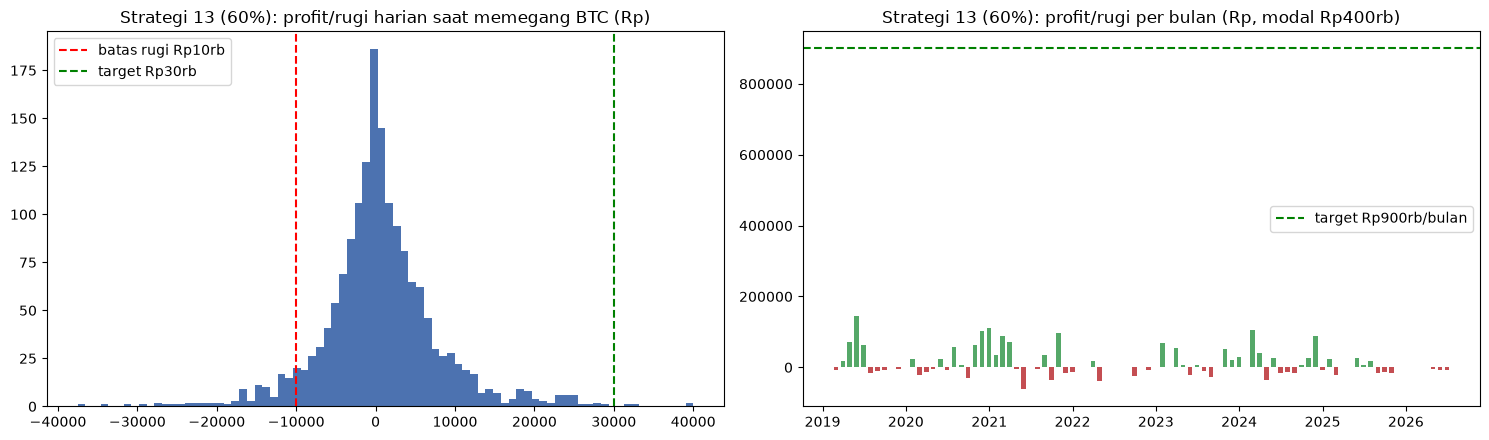

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
d = daily_idr["Strategi 13, porsi 60%"]
axes[0].hist(d[d != 0].clip(-40_000, 40_000), bins=80, color="#4C72B0")
axes[0].axvline(-RUGI_MAKS_HARIAN, color="red", ls="--", label="batas rugi Rp10rb")
axes[0].axvline(TARGET_HARIAN, color="green", ls="--", label="target Rp30rb")
axes[0].set_title("Strategi 13 (60%): profit/rugi harian saat memegang BTC (Rp)"); axes[0].legend()
mon = equity(STRATS["Strategi 13, porsi 60%"]).resample("ME").last().pct_change().dropna() * MODAL
axes[1].bar(mon.index, mon.values, width=20, color=np.where(mon > 0, "#55A868", "#C44E52"))
axes[1].axhline(TARGET_HARIAN * 30, color="green", ls="--", label="target Rp900rb/bulan")
axes[1].set_title("Strategi 13 (60%): profit/rugi per bulan (Rp, modal Rp400rb)"); axes[1].legend()
plt.tight_layout(); plt.show()

## 3. Kendala order minimum ($5) untuk modal $24.5

V2 membagi modal ke 8 coin. Dengan porsi 60%, rata-rata tiap coin hanya sebagian kecil modal —
kalau di bawah $5, order **ditolak exchange**.

In [5]:
cap_usd = MODAL / KURS
wv = (wv2 * 0.6).loc[PERIOD[0]:PERIOD[1]]
held = wv[wv.sum(axis=1) > 0]
per_coin_usd = held * cap_usd
print(f"Modal ${cap_usd:.2f}. Saat risk-on, nilai order per coin (V2 porsi 60%):")
print(per_coin_usd.replace(0, np.nan).describe().loc[["mean", "min", "max"]].T.rename(index=lambda s: s[:-4]).round(2).to_string())
print(f"\nHari risk-on di mana minimal 1 coin < $5 (order ditolak): {(per_coin_usd.where(per_coin_usd > 0) < MIN_ORDER_USD).any(axis=1).mean():.0%}")
print(f"Modal minimum agar SEMUA 8 coin >= $5: ≈ ${MIN_ORDER_USD / held.replace(0, np.nan).min(axis=1).median():.0f} "
      f"(≈ Rp{MIN_ORDER_USD / held.replace(0, np.nan).min(axis=1).median() * KURS:,.0f})")
print(f"Strategi 13 porsi 60%: order BTC = ${cap_usd * 0.6:.2f} → {'OK' if cap_usd * 0.6 >= MIN_ORDER_USD else 'DITOLAK'}")

Modal $24.54. Saat risk-on, nilai order per coin (V2 porsi 60%):
      mean   min   max
BTC   2.52  1.64  4.02
ETH   1.92  1.13  2.91
BNB   2.14  0.92  3.25
XRP   1.77  0.46  2.86
ADA   1.57  0.70  2.26
LINK  1.41  0.81  2.36
TRX   2.31  0.58  4.11
DOGE  1.24  0.24  1.47

Hari risk-on di mana minimal 1 coin < $5 (order ditolak): 100%
Modal minimum agar SEMUA 8 coin >= $5: ≈ $114 (≈ Rp1,850,513)
Strategi 13 porsi 60%: order BTC = $14.72 → OK


## 4. Uji aturan "rugi harian maks Rp10.000"

### 4a. Porsi berapa agar rugi harian hampir tidak pernah > Rp10rb?
Rugi harian ≈ porsi × penurunan harga BTC. Dicari porsi maksimum agar rugi > Rp10rb terjadi di ≤ 1% hari
dan agar hari terburuk historis ≤ Rp10rb.

In [6]:
rows = []
for k in (1.0, 0.6, 0.4, 0.3, 0.2, 0.1, 0.05):
    eq = equity(w13 * k)
    d = eq.pct_change().dropna() * MODAL
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    rows.append({"porsi BTC": f"{k:.0%}", "nilai posisi ($)": round(cap_usd * k, 2),
                 "order >= $5?": "ya" if cap_usd * k >= MIN_ORDER_USD else "TIDAK",
                 "% hari rugi > Rp10rb": f"{(d < -RUGI_MAKS_HARIAN).mean():.2%}",
                 "hari terburuk": f"Rp{d.min():,.0f}",
                 "profit/tahun": f"{(eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1:+.1%}",
                 "rata2 profit/bulan": f"Rp{eq.resample('ME').last().pct_change().dropna().mean() * MODAL:,.0f}"})
pd.DataFrame(rows).set_index("porsi BTC")

,nilai posisi ($),order >= $5?,% hari rugi > Rp10rb,hari terburuk,profit/tahun,rata2 profit/bulan
porsi BTC,,,,,,
100%,24.54,ya,7.34%,"Rp-53,882",+59.0%,"Rp20,052"
60%,14.72,ya,3.58%,"Rp-37,538",+36.1%,"Rp12,101"
40%,9.82,ya,1.57%,"Rp-27,217",+24.2%,"Rp8,089"
30%,7.36,ya,0.69%,"Rp-21,347",+18.2%,"Rp6,074"
20%,4.91,TIDAK,0.15%,"Rp-14,913",+12.1%,"Rp4,055"
10%,2.45,TIDAK,0.00%,"Rp-7,832",+6.0%,"Rp2,030"
5%,1.23,TIDAK,0.00%,"Rp-4,017",+3.0%,"Rp1,016"


### 4b. Aturan "stop harian": kalau rugi hari ini > Rp10rb → jual semua, tunggu sinyal baru

Disimulasikan dengan harga harian: kalau return close-ke-close hari itu membuat rugi > Rp10rb, posisi
dianggap ditutup di batas rugi (optimistis — kenyataannya bisa lebih buruk karena slippage), lalu cash
sampai sinyal pasar mati lalu hidup lagi.

In [7]:
def daily_stop_sim(k, stop_idr=RUGI_MAKS_HARIAN):
    dates = P.dates[(P.dates >= PERIOD[0]) & (P.dates <= PERIOD[1])]
    sig = market.shift(1).fillna(False).loc[dates].to_numpy()          # keputusan kemarin
    o, lo, c = (P.open[BTC].loc[dates].to_numpy(), P.low[BTC].loc[dates].to_numpy(), P.close[BTC].loc[dates].to_numpy())
    v, blocked, pos, eq, stops = 1.0, False, False, [], 0
    prev_sig = False
    for i in range(len(dates)):
        if not sig[i]:
            blocked = False                                              # sinyal mati -> reset blokir
        want = sig[i] and not blocked
        if want and not pos:
            v *= 1 - k * 0.0015; pos = True
        elif not want and pos:
            v *= 1 - k * 0.0015; pos = False
        if pos:
            stop_ret = -(stop_idr / (MODAL * v)) / k                     # penurunan BTC yang = rugi Rp10rb
            day_low_ret = lo[i] / o[i] - 1
            if day_low_ret <= stop_ret:
                v *= 1 + k * stop_ret; v *= 1 - k * 0.0015; pos = False; blocked = True; stops += 1
            else:
                v *= 1 + k * (c[i] / o[i] - 1)
            if pos and i + 1 < len(dates):
                v *= 1 + k * (o[i + 1] / c[i] - 1)                       # gap semalam
        eq.append(v)
    return pd.Series(eq, index=dates), stops

rows = []
for k in (1.0, 0.6):
    for stop in (None, RUGI_MAKS_HARIAN):
        if stop is None:
            eq = equity(w13 * k); n_stop = 0
        else:
            eq, n_stop = daily_stop_sim(k, stop)
        yrs = (eq.index[-1] - eq.index[0]).days / 365.25
        d = eq.pct_change().dropna() * MODAL
        rows.append({"aturan": f"porsi {k:.0%}, " + ("tanpa stop harian" if stop is None else "stop rugi Rp10rb/hari"),
                     "profit total": f"{eq.iloc[-1] / eq.iloc[0] - 1:+.0%}",
                     "profit/tahun": f"{(eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1:+.1%}",
                     "max drawdown": f"{(eq / eq.cummax() - 1).min():+.0%}",
                     "kena stop (kali)": n_stop, "hari terburuk": f"Rp{d.min():,.0f}"})
pd.DataFrame(rows).set_index("aturan")

,profit total,profit/tahun,max drawdown,kena stop (kali),hari terburuk
aturan,,,,,
"porsi 100%, tanpa stop harian",+3129%,+59.0%,-39%,0,"Rp-53,882"
"porsi 100%, stop rugi Rp10rb/hari",+83%,+8.4%,-13%,32,"Rp-11,786"
"porsi 60%, tanpa stop harian",+910%,+36.1%,-25%,0,"Rp-37,538"
"porsi 60%, stop rugi Rp10rb/hari",+62%,+6.6%,-11%,26,"Rp-10,874"


## 5. Biaya VPS vs profit realistis

In [8]:
for vps in (50_000, 100_000, 150_000):
    for name in ("Strategi 13, porsi 60%", "Strategi 13, porsi 100%"):
        mon = equity(STRATS[name]).resample("ME").last().pct_change().dropna() * MODAL
        print(f"VPS Rp{vps:,}/bulan | {name}: rata2 profit Rp{mon.mean():,.0f}/bulan → "
              f"{'cukup' if mon.mean() >= vps else 'TIDAK cukup'}; bulan profit >= VPS: {(mon >= vps).mean():.0%}")
    print()
for name in ("Strategi 13, porsi 60%",):
    eq = equity(STRATS[name])
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = (eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1
    need = 100_000 * 12 / cagr
    print(f"Agar rata2 profit {name} = Rp100rb/bulan (bayar VPS), modal yang dibutuhkan ≈ Rp{need:,.0f}")

VPS Rp50,000/bulan | Strategi 13, porsi 60%: rata2 profit Rp12,101/bulan → TIDAK cukup; bulan profit >= VPS: 17%
VPS Rp50,000/bulan | Strategi 13, porsi 100%: rata2 profit Rp20,052/bulan → TIDAK cukup; bulan profit >= VPS: 20%

VPS Rp100,000/bulan | Strategi 13, porsi 60%: rata2 profit Rp12,101/bulan → TIDAK cukup; bulan profit >= VPS: 4%
VPS Rp100,000/bulan | Strategi 13, porsi 100%: rata2 profit Rp20,052/bulan → TIDAK cukup; bulan profit >= VPS: 13%

VPS Rp150,000/bulan | Strategi 13, porsi 60%: rata2 profit Rp12,101/bulan → TIDAK cukup; bulan profit >= VPS: 0%
VPS Rp150,000/bulan | Strategi 13, porsi 100%: rata2 profit Rp20,052/bulan → TIDAK cukup; bulan profit >= VPS: 6%

Agar rata2 profit Strategi 13, porsi 60% = Rp100rb/bulan (bayar VPS), modal yang dibutuhkan ≈ Rp3,319,700


## 6. Target diturunkan: Rp3.000 per hari (permintaan user berikutnya)

Rp3.000/hari = 0.75% per hari = ±Rp90.000/bulan (22.5% modal per bulan). Dicek: seberapa sering tercapai,
dan modal berapa yang dibutuhkan agar **rata-rata** profit Rp3.000/hari.

In [9]:
T3 = 3_000
rows = []
for name in ("Strategi 13, porsi 60%", "Strategi 13, porsi 100%"):
    eq = equity(STRATS[name])
    d = eq.pct_change().dropna() * MODAL
    mon = eq.resample("ME").last().pct_change().dropna()
    avg_day = d.mean()
    rows.append({"strategi": name,
                 "rata2 profit/hari (Rp400rb)": f"Rp{avg_day:,.0f}",
                 "% hari profit >= Rp3rb": f"{(d >= T3).mean():.1%}",
                 "% hari rugi": f"{(d < 0).mean():.1%}",
                 "% bulan profit >= Rp90rb": f"{(mon * MODAL >= T3 * 30).mean():.1%}",
                 "modal agar rata2 Rp3rb/hari": f"Rp{T3 / (avg_day / MODAL):,.0f}"})
pd.DataFrame(rows).set_index("strategi").T

strategi,"Strategi 13, porsi 60%","Strategi 13, porsi 100%"
rata2 profit/hari (Rp400rb),Rp382,Rp621
% hari profit >= Rp3rb,18.0%,22.6%
% hari rugi,29.8%,29.8%
% bulan profit >= Rp90rb,5.6%,14.6%
modal agar rata2 Rp3rb/hari,"Rp3,144,692","Rp1,933,599"


## Kesimpulan

### 1. Target harian tidak bisa dicapai strategi mana pun
- Rp30rb/hari = **7.5% per hari**. Kalau bisa diputar, Rp400rb jadi **Rp3,5 juta dalam sebulan** dan
  angka tak masuk akal dalam setahun. Tanpa diputar pun = **225% per bulan**.
- Data 2019–2026: hari dengan profit ≥ Rp30rb hanya **0.1%** hari (strategi 13 porsi 60%) — sekitar
  **sekali tiap 3 tahun**. Bahkan buy & hold BTC cuma 2.5% hari.
- "Rugi 0 / tidak boleh minus": **30% hari berakhir rugi** di strategi terbaik; itu sifat pasar.

### 2. Profit realistis dengan modal Rp400rb
| | Strategi 13 porsi 60% | Strategi 13 porsi 100% |
|---|---|---|
| Rata-rata profit / bulan | **±Rp12.000** | **±Rp20.000** |
| Median profit / bulan | Rp0 (setengah waktu memegang cash) | Rp0 |
| % bulan untung | 42% | 42% |
| Bulan terburuk | −Rp62.000 | −Rp103.000 |
| Hari terburuk | −Rp37.500 | −Rp53.900 |
| % hari rugi > Rp10rb | 3.6% | 7.4% |

### 3. Aturan "rugi maks Rp10rb/hari" merusak strategi
- Stop harian Rp10rb: profit/tahun turun dari **+36% → +6.6%** (porsi 60%) karena posisi sering ditutup di
  titik terburuk lalu ketinggalan kenaikan (32 kali kena stop). Drawdown memang turun (−25% → −11%).
- Agar hari terburuk ≤ Rp10rb tanpa stop, porsi BTC harus ≤ ±13% → nilai order ±$3 → **di bawah order minimum $5**
  (ditolak exchange), dan profit tinggal ±6%/tahun.

### 4. Portofolio V2 tidak bisa dijalankan dengan Rp400rb
Membagi $24.5 ke 8 coin → tiap order $0.2–4 (**selalu di bawah minimum $5**). V2 butuh modal minimal
**±Rp1,85 juta** (lebih aman ±Rp2,5 juta).

### 5. Biaya VPS
Rata-rata profit Rp12–20rb/bulan **tidak menutup VPS** Rp50–150rb. Agar rata-rata profit ±Rp100rb/bulan
dibutuhkan modal **±Rp3,3 juta** (strategi 13 porsi 60%). Catatan: strategi ini cukup dicek **sekali sehari**,
jadi tidak butuh VPS mahal — bisa di server backend yang sudah ada atau layanan gratis/terjadwal.

### Manajemen yang realistis untuk modal Rp400rb
1. **Strategi**: 13 (BTC saja, H8b), porsi **60%** (order ±$14.7, di atas minimum).
2. **Batas rugi**: bukan per hari, tapi **total** — *kill switch* kalau modal turun ke **Rp280rb (−30%)**:
   bot berhenti, dievaluasi manual. Drawdown historis porsi 60% = −25%.
3. **Ekspektasi**: rata-rata ±Rp12rb/bulan, **banyak bulan Rp0 atau minus**, hasil ±36%/tahun dalam jangka panjang
   (masa lalu, bukan jaminan).
4. **Anggap Rp400rb sebagai uji nyata bot** (membuktikan eksekusi, log, keamanan API), bukan sumber penghasilan.
5. Naik ke **V2 portofolio** setelah modal ≥ ±Rp2–2,5 juta.

**Target Rp3.000/hari** (bagian 6): rata-rata realistis dengan Rp400rb hanya ±Rp400–660/hari; hari dengan
profit ≥ Rp3rb memang cukup sering, tapi diimbangi hari rugi dan hari cash. Agar **rata-rata** Rp3.000/hari
dibutuhkan modal ±Rp1,9 juta (porsi 100%) s/d ±Rp3,1 juta (porsi 60%).

"Kalau modal kecil bisa untung, modal besar juga" **benar dalam persen** (±36%/tahun sama untuk Rp400rb dan
Rp40 juta), tapi **dalam rupiah** modal kecil menghasilkan angka kecil — itu matematika, bukan kelemahan strategi.